PHẦN 1: TIỀN XỬ LÝ VÀ TRỰC QUAN HÓA DỮ LIỆU

In [1]:
#Nạp và Khám phá dữ liệu
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

titanic = sns.load_dataset('titanic')

print("--- 5 dòng đầu tiên của tập dữ liệu ---")
print(titanic.head())

print("\n--- Thông tin tổng quan của dữ liệu ---")
titanic.info()

--- 5 dòng đầu tiên của tập dữ liệu ---
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

--- Thông tin tổng quan của dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count 

In [2]:
#Xử lý giá trị khuyết
print("--- Số lượng giá trị khuyết ở mỗi cột ---")
print(titanic.isnull().sum())

titanic.drop(columns=['deck'], inplace=True)
print("\nĐã xóa cột 'deck'. Các cột còn lại:", titanic.columns.tolist())

mean_age = titanic['age'].mean()
titanic['age'].fillna(mean_age, inplace=True)
print(f"\nĐã điền các giá trị khuyết của cột 'age' bằng giá trị trung bình: {mean_age:.2f}")

print("Số giá trị khuyết còn lại ở cột 'age':", titanic['age'].isnull().sum())

--- Số lượng giá trị khuyết ở mỗi cột ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Đã xóa cột 'deck'. Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

Đã điền các giá trị khuyết của cột 'age' bằng giá trị trung bình: 29.70
Số giá trị khuyết còn lại ở cột 'age': 0


/tmp/ipykernel_350/340907133.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(mean_age, inplace=True)


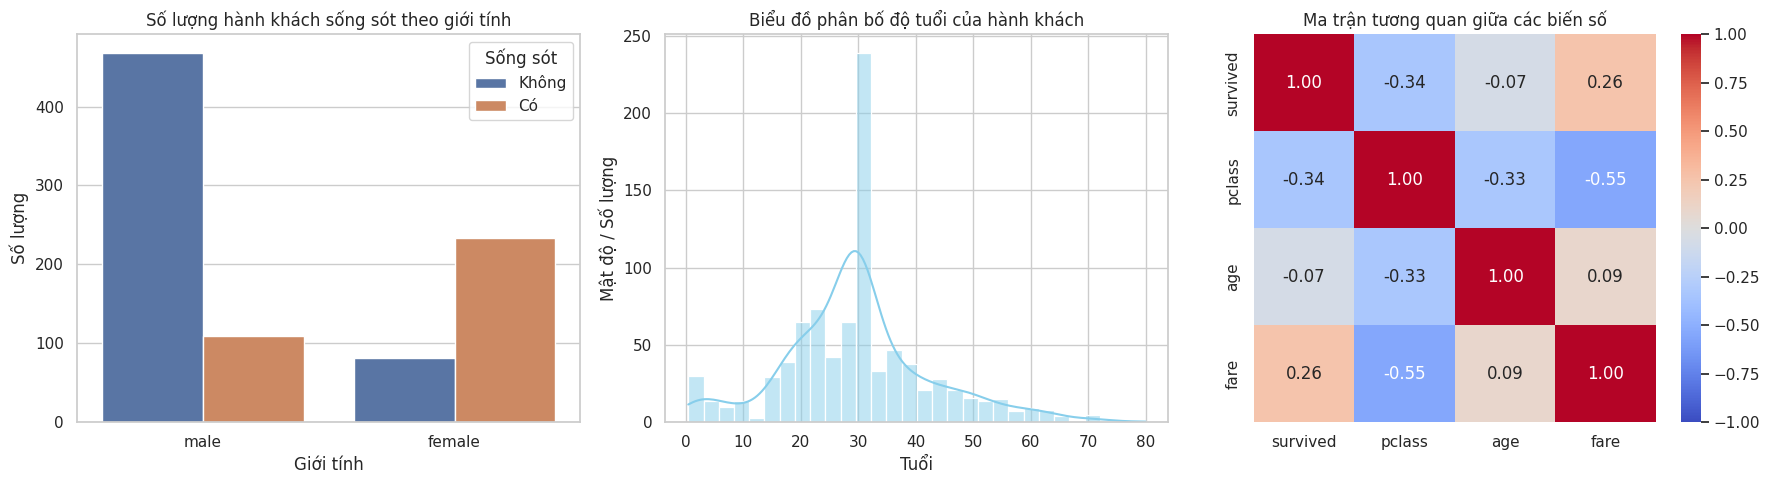

In [3]:
# Phân tích và Trực quan hóa
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=titanic, x='sex', hue='survived')
plt.title('Số lượng hành khách sống sót theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
plt.legend(title='Sống sót', labels=['Không', 'Có'])

plt.subplot(1, 3, 2)
sns.histplot(data=titanic, x='age', kde=True, color='skyblue')
plt.title('Biểu đồ phân bố độ tuổi của hành khách')
plt.xlabel('Tuổi')
plt.ylabel('Mật độ / Số lượng')

plt.subplot(1, 3, 3)
numerical_cols = ['survived', 'pclass', 'age', 'fare']
correlation_matrix = titanic[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa các biến số')

# Hiển thị tất cả biểu đồ
plt.tight_layout()
plt.show()

In [4]:
# Câu 4: Mã hóa dữ liệu (1.5 điểm)

sex_mapping = {'male': 0, 'female': 1}
titanic['sex'] = titanic['sex'].map(sex_mapping)

print("--- Kết quả sau khi mã hóa cột 'sex' ---")
print(titanic[['sex']].head())

titanic = pd.concat([titanic, embarked_dummies], axis=1)

print("\n--- Kết quả sau khi One-Hot Encoding cột 'embarked' và gộp vào DataFrame ---")

new_cols = [col for col in titanic.columns if 'embarked_' in col]
print(titanic[new_cols].head())

--- Kết quả sau khi mã hóa cột 'sex' ---
   sex
0    0
1    1
2    1
3    1
4    0

--- Kết quả sau khi One-Hot Encoding cột 'embarked' và gộp vào DataFrame ---
   embarked_C  embarked_Q  embarked_S
0           0           0           1
1           1           0           0
2           0           0           1
3           0           0           1
4           0           0           1


PHẦN 2: XÂY DỰNG MÔ HÌNH HỌC SÂU CƠ BẢN

In [5]:
#Chuẩn bị dữ liệu cho Học sâu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['pclass', 'sex', 'age']
X = titanic[features]
y = titanic['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Kích thước tập X_train:", X_train_scaled.shape)
print("Kích thước tập X_test:", X_test_scaled.shape)

Kích thước tập X_train: (712, 3)
Kích thước tập X_test: (179, 3)


In [6]:
#Xây dựng mạng Nơ-ron nhân tạo (ANN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(3,)))

model.add(Dense(1, activation='sigmoid'))

model.summary()

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\n--- Bắt đầu huấn luyện mô hình ---")
history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, verbose=1)

print("\n--- Đánh giá mô hình trên tập kiểm thử (Test) ---")
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Loss trên tập test: {loss:.4f}")
print(f"Độ chính xác (Accuracy) trên tập test: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình ---
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5183 - loss: 0.7158   
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5815 - loss: 0.6747 
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6587 - loss: 0.6416 
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7514 - loss: 0.6126 
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7697 - loss: 0.5885 
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7739 - loss: 0.5667 
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7725 - loss: 0.5476 
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7697 - loss: 0.5310 
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7669 - loss: 0.5171 
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7697 - loss: 0.5050 
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7683 - loss: 0.4953 
Epoch 12/20
23/23 ━━━━━━━